Dataset Shape: (301, 9)
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

Data Types After Encoding:
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type          int64
Selling_type       int64
Transmission       int64
Owner              int64
Car_Age            int64
dtype: object

MODEL PERFORMANCE
MAE: 1.221932362175385
R2 Score: 0.8466902419663827


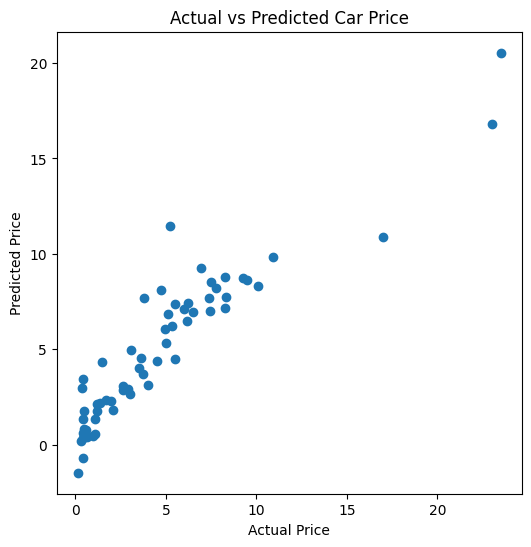


Model Coefficients:
[ 4.39871085e-01 -5.49123474e-06 -1.32453385e+00 -1.16968313e+00
 -1.63747100e+00 -9.21466562e-01 -3.62731319e-01]


In [1]:
# =========================
# TASK 3 - CAR PRICE PREDICTION
# =========================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 2. LOAD DATASET
df = pd.read_csv("/content/car data.csv")

# 3. BASIC INFO
print("Dataset Shape:", df.shape)
print(df.head())

# 4. DROP UNNECESSARY COLUMN
if 'Car_Name' in df.columns:
    df = df.drop('Car_Name', axis=1)

# 5. CREATE NEW FEATURE (CAR AGE)
df['Car_Age'] = 2026 - df['Year']
df = df.drop('Year', axis=1)

# 6. ENCODE ALL CATEGORICAL COLUMNS (FIXED ERROR HERE)
le = LabelEncoder()

categorical_cols = ['Fuel_Type', 'Selling_type', 'Transmission']

for col in categorical_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

# 7. CHECK DATA TYPES (IMPORTANT DEBUG STEP)
print("\nData Types After Encoding:")
print(df.dtypes)

# 8. FEATURES AND TARGET
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# 9. TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 10. MODEL TRAINING
model = LinearRegression()
model.fit(X_train, y_train)

# 11. PREDICTIONS
y_pred = model.predict(X_test)

# 12. EVALUATION
print("\n=========================")
print("MODEL PERFORMANCE")
print("=========================")

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# 13. VISUALIZATION
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")
plt.show()

# 14. MODEL COEFFICIENTS (OPTIONAL INSIGHT)
print("\nModel Coefficients:")
print(model.coef_)